In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [24]:
teste = pd.read_csv(r'C:\Users\Pedro\Documents\GitHub\ML1_AV2_FinalProject\clean_data\test_clean.csv')
treino = pd.read_csv(r'C:\Users\Pedro\Documents\GitHub\ML1_AV2_FinalProject\clean_data\train_clean.csv')

teste0 = sm.add_constant(teste)

In [25]:
X1 = treino.drop('SeriousDlqin2yrs', axis=1)
y = treino['SeriousDlqin2yrs']

X1 = sm.add_constant(X1)
logit_model1 = sm.Logit(y, X1)
logit_result1 = logit_model1.fit()

teste1 = teste0.drop(teste0.columns[[1]], axis=1)

df_t = pd.DataFrame({
    'real': teste['SeriousDlqin2yrs'],
    'Logit1': logit_result1.predict(teste1)
})
print(logit_result1.summary())

Optimization terminated successfully.
         Current function value: 0.232889
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
Model:                          Logit   Df Residuals:                   120258
Method:                           MLE   Df Model:                           10
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                 0.07696
Time:                        16:54:25   Log-Likelihood:                -28009.
converged:                       True   LL-Null:                       -30345.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.4724      0.0

In [26]:
X2 = X1.drop(X1.columns[[1,6]], axis=1)

Logit_model2 = sm.Logit(y, X2)
logit_result2 = Logit_model2.fit()

teste2 = teste1.drop(teste1.columns[[1,6]],axis=1)

df_t['Logit2'] = logit_result2.predict(teste2)
print(logit_result2.summary())

Optimization terminated successfully.
         Current function value: 0.232906
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
Model:                          Logit   Df Residuals:                   120260
Method:                           MLE   Df Model:                            8
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                 0.07690
Time:                        16:54:26   Log-Likelihood:                -28011.
converged:                       True   LL-Null:                       -30345.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.4865      0.0

In [27]:
X3 = X2.drop(X2.columns[[5,7]],axis=1)

X3.head()

Logit_model3 = sm.Logit(y, X3)
Logit_result3 = Logit_model3.fit()

print(Logit_result3.summary())

teste3 = teste2.drop(teste2.columns[[5,7]], axis=1)

df_t['Logit3'] = Logit_result3.predict(teste3)

Optimization terminated successfully.
         Current function value: 0.242717
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
Model:                          Logit   Df Residuals:                   120262
Method:                           MLE   Df Model:                            6
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                 0.03801
Time:                        16:54:26   Log-Likelihood:                -29191.
converged:                       True   LL-Null:                       -30345.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.2753      0.0

In [ ]:
X4 = X2.drop(X2.columns[[5]],axis=1)
teste4 = teste2.drop(teste2.columns[[5]],axis=1)
X4['interaction_term'] = X4.iloc[:,2] * X4.iloc[:,6]
teste4['interaction_term'] = teste4.iloc[:,2] * teste4.iloc[:,6]

X5 = X2.drop(X2.columns[[2]],axis=1)
teste5 = teste2.drop(teste2.columns[[2]],axis=1)
X5['interaction_term'] = X5.iloc[:,4] * X5.iloc[:,6]
teste5['interaction_term'] = teste5.iloc[:,4] * teste5.iloc[:,6]

X6 = X2.drop(X2.columns[[6]],axis=1)
teste6 = teste2.drop(teste2.columns[[6]],axis=1)
X6['interaction_term'] = X6.iloc[:,2] * X6.iloc[:,5]
teste6['interaction_term'] = teste6.iloc[:,2] * teste6.iloc[:,5]

logit_model4 = sm.Logit(y, X4)
Logit_result4 = logit_model4.fit()
df_t['Logit4'] = Logit_result4.predict(teste4)

Logit_mode5 = sm.Logit(y, X5)
Logit_result5 = Logit_mode5.fit()
df_t['Logit5'] = Logit_result5.predict(teste5)

Logit_mode6 = sm.Logit(y, X6)
Logit_result6 = Logit_mode6.fit()
df_t['Logit6'] = Logit_result6.predict(teste6)

Optimization terminated successfully.
         Current function value: 0.216529
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.215322
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.207014
         Iterations 8


In [29]:
n = len(df_t)

def adjusted_r2(y, yhat, p): #usando o R^2 pois cada modelo tem um número diferente de preditores
    if n - p - 1 <= 0:
        return float('nan')
    r2 = r2_score(y, yhat)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

p1 = X1.shape[1] - 1
p2 = X2.shape[1] - 1
p3 = X3.shape[1] - 1
p4 = X4.shape[1] - 1
p5 = p4
p6 = p4

nds = pd.DataFrame({
    'Modelo': ['Logit 1', 'Logit 2', 'Logit 3', 'Logit 4', 'Logit 5', 'Logit 6'],
    'MSE': [
        mean_squared_error(df_t['real'], df_t['Logit1']),
        mean_squared_error(df_t['real'], df_t['Logit2']),
        mean_squared_error(df_t['real'], df_t['Logit3']),
        mean_squared_error(df_t['real'], df_t['Logit4']),
        mean_squared_error(df_t['real'], df_t['Logit5']),
        mean_squared_error(df_t['real'], df_t['Logit6'])
    ],
    'MAE': [
        mean_absolute_error(df_t['real'], df_t['Logit1']),
        mean_absolute_error(df_t['real'], df_t['Logit2']),
        mean_absolute_error(df_t['real'], df_t['Logit3']),
        mean_absolute_error(df_t['real'], df_t['Logit4']),
        mean_absolute_error(df_t['real'], df_t['Logit5']),
        mean_absolute_error(df_t['real'], df_t['Logit6'])
    ],
    'Corr (Pearson)': [
        df_t['real'].corr(df_t['Logit1']),
        df_t['real'].corr(df_t['Logit2']),
        df_t['real'].corr(df_t['Logit3']),
        df_t['real'].corr(df_t['Logit4']),
        df_t['real'].corr(df_t['Logit5']),
        df_t['real'].corr(df_t['Logit6'])
    ],
    'Adj R2': [
        adjusted_r2(df_t['real'], df_t['Logit1'], p1),
        adjusted_r2(df_t['real'], df_t['Logit2'], p2),
        adjusted_r2(df_t['real'], df_t['Logit3'], p3),
        adjusted_r2(df_t['real'], df_t['Logit4'], p4),
        adjusted_r2(df_t['real'], df_t['Logit5'], p5),
        adjusted_r2(df_t['real'], df_t['Logit6'], p6)
    ]

})

nds.head(6), Logit_result6.summary()

(    Modelo       MSE       MAE  Corr (Pearson)    Adj R2
 0  Logit 1  0.008142  0.052814        0.575192  0.330751
 1  Logit 2  0.008151  0.052821        0.574529  0.330003
 2  Logit 3  0.011086  0.063887        0.311764  0.088821
 3  Logit 4  0.006135  0.043906        0.715818  0.495706
 4  Logit 5  0.005058  0.044161        0.773154  0.584266
 5  Logit 6  0.003814  0.037118        0.839209  0.686524,
 <class 'statsmodels.iolib.summary.Summary'>
 """
                            Logit Regression Results                           
 Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
 Model:                          Logit   Df Residuals:                   120260
 Method:                           MLE   Df Model:                            8
 Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                  0.1795
 Time:                        16:54:27   Log-Likelihood:                -24897.
 converged:                       True   LL-Null:              

In [30]:
vif_data = pd.DataFrame({
    'feature': X6.columns,
    'VIF': [variance_inflation_factor(X6.values, i) for i in range(X6.shape[1])]
})
print(vif_data)

                                feature         VIF
0                                 const   16.412273
1                                   age    1.056406
2  NumberOfTime30-59DaysPastDueNotWorse   26.821915
3                             DebtRatio    1.001016
4                         MonthlyIncome    1.007973
5               NumberOfTimes90DaysLate   56.865086
6  NumberOfTime60-89DaysPastDueNotWorse  123.220867
7                    NumberOfDependents    1.052928
8                      interaction_term  128.896374


variáveis > 100 tem alta colinear, então farei alguma regularização para tentar contornar este possível problema.

In [31]:
X6.describe()

,const,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,interaction_term
count,120269.0,120269.000000,120269.000000,120269.000000,1.202690e+05,120269.000000,120269.000000,120269.000000,120269.000000
mean,1.0,51.289792,0.381769,26.598777,6.670221e+03,0.211925,0.187829,0.851832,11.906609
std,0.0,14.426684,3.499234,424.446457,1.438467e+04,3.465276,3.447901,1.148391,336.335307
min,1.0,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1.0,40.000000,0.000000,0.143388,3.400000e+03,0.000000,0.000000,0.000000,0.000000
50%,1.0,51.000000,0.000000,0.296023,5.400000e+03,0.000000,0.000000,0.000000,0.000000
75%,1.0,61.000000,0.000000,0.482559,8.249000e+03,0.000000,0.000000,2.000000,0.000000
max,1.0,103.000000,98.000000,61106.500000,3.008750e+06,98.000000,98.000000,20.000000,9604.000000


## DAQUI EM DIANTE ESTÁ DANDO PAU, ESTOU TRABALHANDO PARA RESOLVER!

c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.20624125212194616
            Iterations: 47
            Function evaluations: 69
            Gradient evaluations: 47


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 8 out of 9 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.2072259382981032
            Iterations: 48
            Function evaluations: 68
            Gradient evaluations: 48


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 5 out of 9 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


...

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.21046292839943137
            Iterations: 61
            Function evaluations: 81
            Gradient evaluations: 61


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 9 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.21123497524709678
            Iterations: 59
            Function evaluations: 79
            Gradient evaluations: 59
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.21401881080123206
            Iterations: 54
            Function evaluations: 74
            Gradient evaluations: 54
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.21499606692131845
            Iterations: 51
            Function evaluations: 71
            Gradient evaluations: 51
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.2158153416668389
            Iterations: 51
            Function evaluations: 71
            Gradient evaluations: 51
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.2140828829444551
            Iterations: 52
            Function 

c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 1 out of 9 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.23246468605437504
            Iterations: 35
            Function evaluations: 54
            Gradient evaluations: 35
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.23049528592087115
            Iterations: 31
            Function evaluations: 51
            Gradient evaluations: 31
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.23096790180257512
            Iterations: 31
            Function evaluations: 52
            Gradient evaluations: 31
Best lambda:  0.01


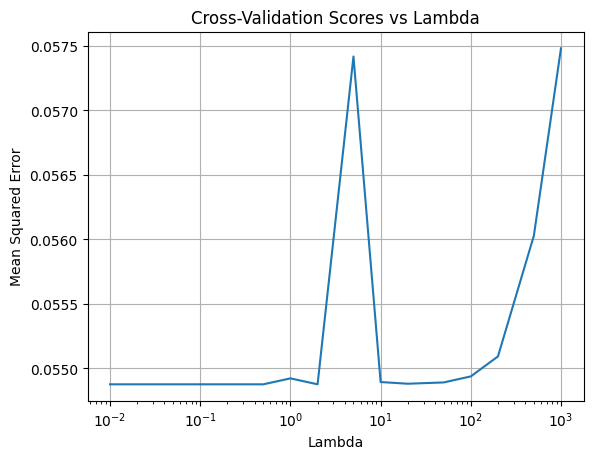

In [32]:
from sklearn.model_selection import KFold

# preparar os dados: features X (remover MonthlyIncome) e alvo binário y (SeriousDlqin2yrs)
# X6 foi construído a partir do conjunto de treino, então removemos a coluna contínua 'MonthlyIncome'
X = X6

# definir a lista de valores de lambda para testar
lam_list = [0.01, 0.1, 0.5, 1,2, 5, 10, 20, 50, 100, 200, 500, 1000]

# inicializar KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# guardar os scores de cross validation
cv_scores = []

# fazer cross-validation para cada valor de lambda
for lam in lam_list:
    fold_scores = []
    # separação dos dados em folds
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # ajustar modelo logit regularizado (alvo binário)
        ridge_logit = sm.Logit(y_train, X_train).fit_regularized(method='l1', alpha=lam)
        
        # calcular o MSE no fold de validação usando probabilidades previstas
        y_pred = ridge_logit.predict(X_val)
        mse = np.mean((y_val - y_pred)**2)
        fold_scores.append(mse)
    
    cv_scores.append(np.mean(fold_scores))

# Find best lambda
best_lam = lam_list[np.argmin(cv_scores)]
print('Best lambda: ', best_lam)

# Plot CV scores
plt.semilogx(lam_list, cv_scores)
plt.xlabel('Lambda')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validation Scores vs Lambda')
plt.grid(True)

In [33]:
ridge_logit = sm.Logit(y, X).fit_regularized(method='l1', alpha=best_lam)

df_t['Ridge_Logit'] = ridge_logit.predict(X)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.20701416785909543
            Iterations: 48
            Function evaluations: 69
            Gradient evaluations: 48


c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 5 out of 9 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
c:\Users\Pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


In [35]:
n = len(df_t)

def adjusted_r2(y, yhat, p): #usando o R^2 pois cada modelo tem um número diferente de preditores
    if n - p - 1 <= 0:
        return float('nan')
    r2 = r2_score(y, yhat)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

p1 = X1.shape[1] - 1
p2 = X2.shape[1] - 1
p3 = X3.shape[1] - 1
p4 = X4.shape[1] - 1
p5 = p4
p6 = p4
p7 = X.shape[1] - 1

nds = pd.DataFrame({
    'Modelo': ['Logit 1', 'Logit 2', 'Logit 3', 'Logit 4', 'Logit 5', 'Logit 6', 'Ridge Logit'],
    'MSE': [
        mean_squared_error(df_t['real'], df_t['Logit1']),
        mean_squared_error(df_t['real'], df_t['Logit2']),
        mean_squared_error(df_t['real'], df_t['Logit3']),
        mean_squared_error(df_t['real'], df_t['Logit4']),
        mean_squared_error(df_t['real'], df_t['Logit5']),
        mean_squared_error(df_t['real'], df_t['Logit6']),
        mean_squared_error(df_t['real'], df_t['Ridge_Logit'])
    ],
    'MAE': [
        mean_absolute_error(df_t['real'], df_t['Logit1']),
        mean_absolute_error(df_t['real'], df_t['Logit2']),
        mean_absolute_error(df_t['real'], df_t['Logit3']),
        mean_absolute_error(df_t['real'], df_t['Logit4']),
        mean_absolute_error(df_t['real'], df_t['Logit5']),
        mean_absolute_error(df_t['real'], df_t['Logit6']),
        mean_absolute_error(df_t['real'], df_t['Ridge_Logit'])
    ],
    'Corr (Pearson)': [
        df_t['real'].corr(df_t['Logit1']),
        df_t['real'].corr(df_t['Logit2']),
        df_t['real'].corr(df_t['Logit3']),
        df_t['real'].corr(df_t['Logit4']),
        df_t['real'].corr(df_t['Logit5']),
        df_t['real'].corr(df_t['Logit6']),
        df_t['real'].corr(df_t['Ridge_Logit'])
    ],
    'Adj R2': [
        adjusted_r2(df_t['real'], df_t['Logit1'], p1),
        adjusted_r2(df_t['real'], df_t['Logit2'], p2),
        adjusted_r2(df_t['real'], df_t['Logit3'], p3),
        adjusted_r2(df_t['real'], df_t['Logit4'], p4),
        adjusted_r2(df_t['real'], df_t['Logit5'], p5),
        adjusted_r2(df_t['real'], df_t['Logit6'], p6),
        adjusted_r2(df_t['real'], df_t['Ridge_Logit'], p7)
    ]

})

nds.head(7), ridge_logit.summary()

(        Modelo       MSE       MAE  Corr (Pearson)    Adj R2
 0      Logit 1  0.008142  0.052814        0.575192  0.330751
 1      Logit 2  0.008151  0.052821        0.574529  0.330003
 2      Logit 3  0.011086  0.063887        0.311764  0.088821
 3      Logit 4  0.006135  0.043906        0.715818  0.495706
 4      Logit 5  0.005058  0.044161        0.773154  0.584266
 5      Logit 6  0.003814  0.037118        0.839209  0.686524
 6  Ridge Logit  0.023673  0.080508       -0.006200 -0.945822,
 <class 'statsmodels.iolib.summary.Summary'>
 """
                            Logit Regression Results                           
 Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
 Model:                          Logit   Df Residuals:                   120260
 Method:                           MLE   Df Model:                            8
 Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                  0.1795
 Time:                        16:58:40   Log-Likeliho